# finish

In [1]:
#libraries
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import math
import time

In [ ]:
#create dataset
#AR(1) 
def ar_1(n,mu,sigma,phi,seed):
    #y = []
    rng = np.random.default_rng(seed=seed)
    y = np.zeros(n)
    epslon = rng.normal(mu,sigma,n)
    for t in range(1,n):
        y[t] =(phi*y[t-1]) + epslon[t]
    return y


In [ ]:
#create dataset 
#ARMA(1,1)
def arma_11(n,mu,sigma,phiY,phiE,seed):
    rng = np.random.default_rng(seed=seed)
    epslon = rng.normal(mu,sigma,n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = (phiY*y[t-1]) + epslon[t] + (phiE*epslon[t-1])     
    return y

In [ ]:
#create dataset
#Mean shift
def mean_shift(n,mu,sigma,shift_mean,phi,seed):
    rng = np.random.default_rng(seed=seed)
    epslon = rng.normal(mu,sigma,n)
    y = epslon.copy()
    y[shift_mean:] += 1.0  
    for t in range(1, n):
        y[t] = (phi*y[t-1]) + ((1-phi)*y[t])
    return y


In [ ]:
#create dataset 
#GARCH(1,1)
def garch(n,mu,sigma,a,phi,b,seed):
    rng = np.random.default_rng(seed=seed)
    epsol = rng.normal(mu,sigma,n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = epsol[t]*(np.sqrt(a+(phi*(y[t-1]**2))+b))

    return y

In [ ]:
#convert time-series into x,y
# lag = 3
def dataset(lag,y):
    x  = []
    y_target = []
    full_dataset = []
    for t in range(lag,len(y)):
        x.append(y[t-lag:t])
        y_target.append(y[t])
    #full_dataset = x,y_target
    #print(f'len x:{len(x)} len y:{len(y_target)}')
    return x,y_target 

In [7]:
#implement linear regression manually
def fit_linear_regression(X_train,y_train):
    X = np.insert(X_train,0,1,axis=1)
    betas = inv(X.T@X)@X.T@y_train
    return betas


In [8]:
#compute prediction using linear regression 
def prediction_linear(x,betas):
    y_hat = betas[0]+(betas[1]*x[:,0])+(betas[2]*x[:,1])+(betas[3]*x[:,2])
    return y_hat

In [ ]:
#compuite the fix calibrtion score(RESIDUAL)
def calScore(y_cal,y_hat_cal):
    #for i in range(len(y_cal)):
    epslon = np.abs(y_cal-y_hat_cal)
    return epslon

### fine tuning for finding the best gamma0

In [ ]:
#fine-tuning gamma0 
def aci(X_train_tuning,y_train_tuning,X_cal_tuning,y_cal_tuning,X_val,y_val,gammas,alpha):

    betas =  fit_linear_regression(X_train_tuning,y_train_tuning)
    y_hat_cal = prediction_linear(X_cal_tuning,betas)
    epslon = calScore(y_cal_tuning,y_hat_cal)
    epslon_sort = np.sort(epslon)
    n_cal = len(X_cal_tuning)
    #alpha = alpha
    #C = []
    y_hat_val = prediction_linear(X_val,betas)
    #covered = []
    results = []
    for gamma in gammas:
        alpha_t = alpha
        C = []
        errors = []
        widths = []
        for i in range(len(y_val)):
            #compute quantile q for current alpha
            l = np.ceil((1-alpha_t)*(n_cal+1))/n_cal
            position = int(l*n_cal)
            q = epslon_sort[position-1]
            #print(f'quantile: {q}')
            lower = y_hat_val[i] - q
            upper = y_hat_val[i] + q
            C.append((lower,upper))
            #save the width
            widths.append(upper-lower)
            #wait true Y to be revealed to get feedback
            if (y_val[i]>=lower)and(y_val[i]<=upper):
                error = 0
            else:
                error = 1
            errors.append(error)
            #time-dependent step size
            gamma_t = gamma/np.sqrt(i+1)
            #update level for next step
            alpha_new = alpha_t+(gamma_t*(alpha-error))
            alpha_min = 1/(n_cal+1)
            alpha_max = n_cal/(n_cal+1)
            # se x < a  -> restituisci a
            # se x > b  -> restituisci b
            # altrimenti -> restituisci x
            alpha_t = np.clip(alpha_new,alpha_min,alpha_max)
             

        #find coverage
        coverage = 1 - np.mean(errors)
        #find width
        width = np.mean(widths)
        #save reslits
        results.append((gamma,coverage,width))

        # considering only coverage >= .90
        target_coverage = 1-.1
        valid_results = [r for r in results if r[1]>=target_coverage]
        #if time siries have coverage>=.90
        if len(valid_results) > 0:
            # choose gamma with smallest width 
            best_results = min(valid_results,key=lambda r:r[2])
        #if time siries have not coverage >=.90
        #in this case it cosidering biggest coverage just below 0.90
        else:
            best_coverage = max(r[1] for r in results)
            closest_coverage = [r for r in results if r[1] == best_coverage]
            best_results = min(closest_coverage,key=lambda r:r[2])
        best_gamma = best_results[0]
    return results,best_gamma 


In [11]:
def fune_tuning(ar,arma,ms,ga):    
    # ar = ar_1(n=903,mu=0,sigma=1.0,phi=0.8,seed=1234)
    # arma = arma_11(n=903,mu=0,sigma=1.0,phiY=0.5,phiE=0.4,seed=1234)
    # ms = mean_shift(n=903,mu=0,sigma=1.0,shift_mean=600,phi=0.3,seed=1234)
    # ga = garch(n=903,mu=0,sigma=1.0,a=0.3,phi=0.5,b=0.1,seed=1234)
    arr =[ar,arma,ms,ga]
    arr1 = ['ar','arma','ms','ga']
    counter = 0
    final_gammas = []
    final_results = []
    for i in arr:
        x, y = dataset(3,i)
        x = np.array(x)
        y = np.array(y)
        X_train_tuning = x[:200]
        y_train_tuning = y[:200]
        X_cal_tuning = x[200:400]
        y_cal_tuning = y[200:400]
        X_val = x[400:600]
        y_val = y[400:600]
        #ar=0.06,arma=0.01,ms=0.17,ga=0.052
        gammas=[0.001,0.002,0.003,0.004,0.005,0.0052,0.0054,0.0056,0.0058,0.006,0.0062,0.0064,0.0066,0.0068,0.007,0.008,0.009,0.01,0.011,0.12,0.13,0.14,0.15,0.16, 0.162, 0.164, 0.166, 0.168,0.170, 0.172, 0.174, 0.176, 0.178, 0.180,0.17,0.18,0.19,0.02,0.022,0.024,0.026,0.028,0.03,0.04,0.05,0.052,0.054,0.056,0.058,0.06,0.062,0.064,0.066,0.068,0.07,0.08,0.09,0.1]

        #ar=0.006,arma=0.01,ms=0.17,ga=0.052

        _,gamma0=aci(X_train_tuning,y_train_tuning,X_cal_tuning,y_cal_tuning,X_val,y_val,gammas,alpha=.1)
        final_gammas.append(gamma0)
        #ll = arr1[counter]
        #counter+=1
        #final_gammas[ll]=gamma0
        #final_results.append(result)
    return final_gammas

ar = ar_1(n=903,mu=0,sigma=1.0,phi=0.8,seed=1234)
arma = arma_11(n=903,mu=0,sigma=1.0,phiY=0.5,phiE=0.4,seed=1234)
ms = mean_shift(n=903,mu=0,sigma=1.0,shift_mean=600,phi=0.3,seed=1234) #problem ms gamma=0.17 to agressive bring position at 301
ga = garch(n=903,mu=0,sigma=1.0,a=0.3,phi=0.5,b=0.1,seed=1234)

best_gamma0 = fune_tuning(ar,arma,ms,ga)
best_gamma0


[0.0068, 0.01, 0.168, 0.052]

### final ACI(Adaptive Conformal Inference)

In [12]:
#fine-tuning gamma0 
def final_aci(X_train,y_train,X_cal,y_cal,X_test,y_test,gamma0,alpha):

    betas =  fit_linear_regression(X_train,y_train)
    y_hat_cal = prediction_linear(X_cal,betas)
    epslon = calScore(y_cal,y_hat_cal)
    epslon_sort = np.sort(epslon)
    n_cal = len(X_cal)
    #alpha = alpha
    #C = []
    y_hat_test = prediction_linear(X_test,betas)
    #covered = []
    #results = []
    #for gamma in gammas:
    alpha_t = alpha
    C = []
    errors = []
    widths = []
    for i in range(len(y_test)):
        #compute quantile q for current alpha
        l = np.ceil((1-alpha_t)*(n_cal+1))/n_cal
        position = int(l*n_cal)
        q = epslon_sort[position-1]
        #print(f'quantile: {q}')
        lower = y_hat_test[i] - q
        upper = y_hat_test[i] + q
        C.append((lower,upper))
        #save the width
        widths.append(upper-lower)
        #wait true Y to be revealed to get feedback
        if (y_test[i]>=lower)and(y_test[i]<=upper):
            error = 0
        else:
            error = 1
        errors.append(error)
        #time-dependent step size
        gamma_t = gamma0/np.sqrt(i+1)
        #update level for next step
        alpha_new = alpha_t+(gamma_t*(alpha-error))
        alpha_min = 1/(n_cal+1)
        alpha_max = n_cal/(n_cal+1)
        # se x < a  -> restituisci a
        # se x > b  -> restituisci b
        # altrimenti -> restituisci x
        alpha_t = np.clip(alpha_new,alpha_min,alpha_max) 

        # print("gamma0 =", gamma0)
        # print("gamma_t =", gamma_t)
        # print("alpha_t =", alpha_t)
        # print('position =',position)

    #find coverage
    coverage = 1 - np.mean(errors)
    #find width
    width = np.mean(widths)

    return C, coverage, width




In [13]:
def data(ar,arma,ms,ga,best_gamma0):    
    arr =[ar,arma,ms,ga]
    #final_gammas = []
    #final_results = []
    final_times = []
    final_C = []
    final_coverages = []
    final_widths = []
    for i,gamma in zip(arr,best_gamma0):
        #time for each time siries
        start_time = time.time()
        #print(gamma, type(gamma))
        x, y = dataset(3,i)
        x = np.array(x)
        y = np.array(y)
        X_train = x[:300]
        y_train = y[:300]
        X_cal = x[300:600]
        y_cal = y[300:600]
        X_test = x[600:900]
        y_test = y[600:900]

        C,coverage, width = final_aci(X_train,y_train,X_cal,y_cal,X_test,y_test,gamma,alpha=.1)

        end_time = time.time()
        running_time = end_time - start_time
        final_C.append(C)
        final_coverages.append(coverage)
        final_widths.append(width)
        final_times.append(running_time)
    return final_C,final_coverages,final_widths,final_times

ar = ar_1(n=903,mu=0,sigma=1.0,phi=0.8,seed=1234)
arma = arma_11(n=903,mu=0,sigma=1.0,phiY=0.5,phiE=0.4,seed=1234)
ms = mean_shift(n=903,mu=0,sigma=1.0,shift_mean=600,phi=0.3,seed=1234)
ga = garch(n=903,mu=0,sigma=1.0,a=0.3,phi=0.5,b=0.1,seed=1234)
C,coverage,width,timer = data(ar,arma,ms,ga,best_gamma0)
coverage,width,timer


([np.float64(0.89),
  np.float64(0.8966666666666667),
  np.float64(0.8933333333333333),
  np.float64(0.9133333333333333)],
 [np.float64(3.370582341180394),
  np.float64(3.3781707061933512),
  np.float64(3.0414630216515564),
  np.float64(2.983612827134375)],
 [0.006023406982421875,
  0.005813121795654297,
  0.004015207290649414,
  0.006026744842529297])

In [14]:
def confInterval(best_gamma0,aci_di,n_rep):

    names = ['ar','arma','ms','ga']
    coverages = {name: [] for name in names}
    widths = {name: [] for name in names} 

    for seed in range(n_rep):

        #genrate timie siries with actual seed
        ar = ar_1(n=903,mu=0,sigma=1.0,phi=0.8,seed=seed)
        arma = arma_11(n=903,mu=0,sigma=1.0,phiY=0.5,phiE=0.4,seed=seed) 
        ms = mean_shift(n=903,mu=0,sigma=1.0,shift_mean=600,phi=0.3,seed=seed)
        ga = garch(n=903,mu=0,sigma=1.0,a=0.3,phi=0.5,b=0.1,seed=seed)

       #give results aci results of all siries     
        _, coverage_seed, width_seed,_ = data(ar,arma,ms,ga,best_gamma0)

        #coverage and width
        for j, name in enumerate(names):
            coverages[name].append(coverage_seed[j])
            widths[name].append(width_seed[j])

    #centre points
    for name in names:
        cov = np.array(coverages[name])
        wid = np.array(widths[name])
        mean_coverage = np.mean(cov)
        mean_width = np.mean(wid)


        #confidence interval coverage level 95%
        std_coverage = np.sqrt(np.sum((cov-mean_coverage)**2)/(len(cov)-1))
        coverage_err =1.96*std_coverage/np.sqrt(len(cov))  
        #test_cove = 1.96*np.std(coverage,ddof=1)/np.sqrt(len(coverage))
        #coverage interval width level 95%
        std_width = np.sqrt(np.sum((wid-mean_width)**2)/(len(cov)-1))
        width_err =1.96*std_width/np.sqrt(len(wid))  
        #test_width = 1.96*np.std(wid,ddof=1)/np.sqrt(len(wid))
        aci_di[name] = mean_coverage, mean_width, coverage_err, width_err
    #print(f'mean_coverage: {mean_coverage}, coverage_error: {coverage_err}, test_cove: {test_cove}')
    #print(f'mean_width: {mean_width}, width_error: {width_err}, test_width: {test_width}')




    return aci_di


In [15]:
aci_di = {}
aci_di = confInterval(best_gamma0,aci_di,n_rep=50)
#aci_di

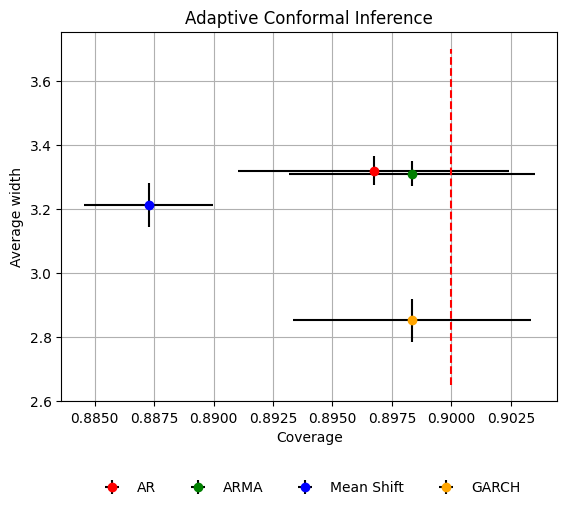

In [16]:
# import matplotlib.pyplot as plt
# import numpy as np

colors = ['red', 'green', 'blue', 'orange']
#colors = ['red']
labels = ['AR', 'ARMA', 'Mean Shift', 'GARCH']
for model, col, lab in zip(['ar','arma','ms','ga'],colors,labels):
    mean_coverage, mean_width, coverage_err, width_err = aci_di[model]
    plt.errorbar(mean_coverage, mean_width, xerr=coverage_err, yerr=width_err, fmt='o', ecolor='black', color=col,label=lab)
plt.vlines(x=0.90,ymin=2.65,ymax=3.7,colors='r',linestyles='--')
plt.title('Adaptive Conformal Inference')
plt.xlabel('Coverage')
plt.ylabel('Average width')
# LEGENDA SOTTO "Coverage"
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    frameon=False
)
plt.grid()
plt.show()



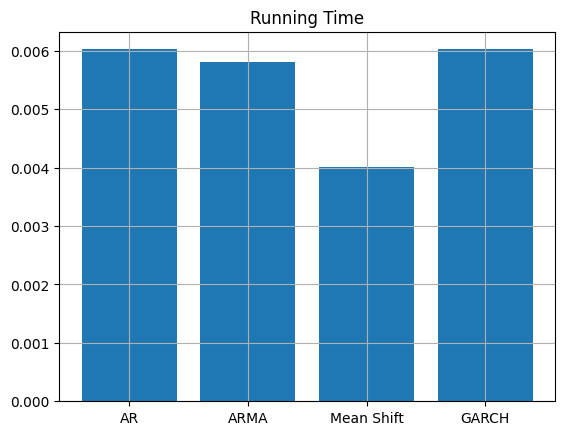

In [17]:
x = ['AR', 'ARMA', 'Mean Shift', 'GARCH']
y = timer
plt.bar(x,y)
plt.title("Running Time")
plt.grid()
plt.show()

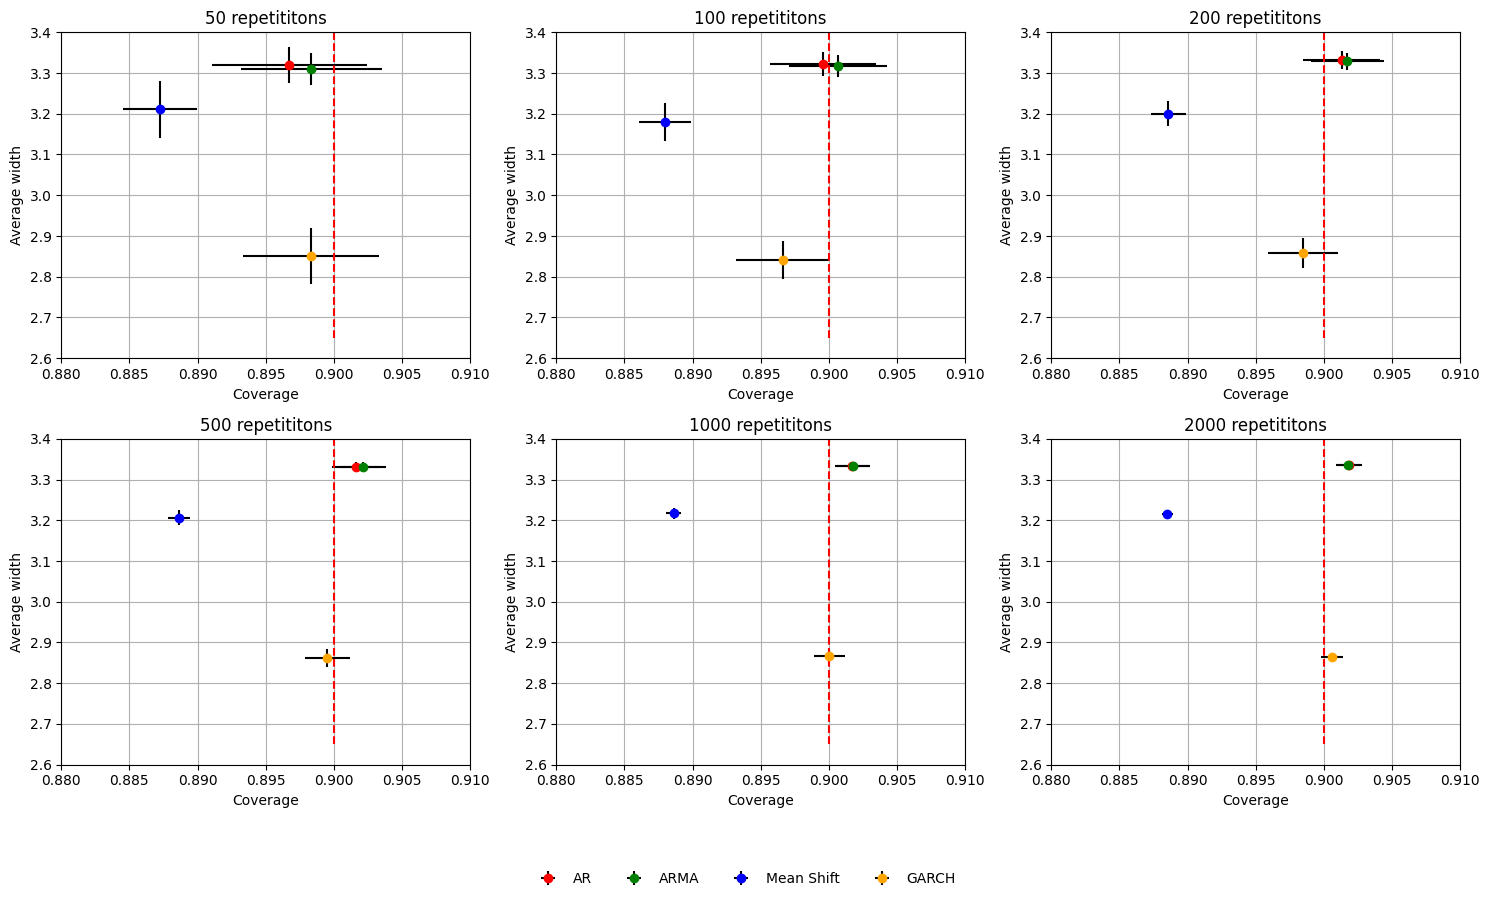

In [26]:
repetiotions = [50,100,200,500,1000,2000]
fig, axes = plt.subplots(2, 3, figsize=(15,9))
axes = axes.flatten()
colors = ['red', 'green', 'blue', 'orange']
labels = ['AR', 'ARMA', 'Mean Shift', 'GARCH']
#models = ['ar','arma','ms','ga']
plt.title('Adaptive Conformal Inference')
for k, n_rep in enumerate(repetiotions):
    #recompute confidence interval
    aci_di = {}
    aci_di = confInterval(best_gamma0,aci_di,n_rep=n_rep)
    ax = axes[k]

    for model, col, lab in zip(['ar','arma','ms','ga'],colors,labels):
        mean_coverage, mean_width, coverage_err, width_err = aci_di[model]
        ax.errorbar(mean_coverage, mean_width, xerr=coverage_err, yerr=width_err, fmt='o', ecolor='black', color=col,label=lab)
    ax.vlines(x=0.90,ymin=2.65,ymax=3.7,colors='r',linestyles='--')
    ax.set_xlim(0.88, 0.91)
    ax.set_ylim(2.6, 3.4)
    ax.set_title(f'{n_rep} repetititons')
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Average width')
    ax.grid()

#remuve sith subplot
#fig.delaxes(axes[5])

#one legend for all plot
handles, legend_labels = axes[0].get_legend_handles_labels()

# LEGENDA SOTTO "Coverage"
fig.legend(
    handles,
    legend_labels,
    loc='lower center',
    ncol=4,
    frameon=False
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()